<a href="https://colab.research.google.com/github/ErenB02/compneuro/blob/main/project/MNE_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
# @title Data retrieval
import os, requests

fname = 'fingerflex.npz'
url = "https://osf.io/5m47z/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [2]:
# @title Data loading
import numpy as np

alldat = np.load(fname, allow_pickle=True)['dat']

# Select just one of the recordings here. This is subject 1, block 1.
dat = alldat[0][0]

print(dat.keys())

dict_keys(['V', 'dg', 't_on', 't_off', 'stim_id', 'stimtext', 'srate', 'locs', 'hemisphere', 'lobe', 'gyrus', 'Brodmann_Area'])


In [11]:
# !pip install -q mne pyvista trame trame-vtk trame-vuetify ipympl

from IPython import get_ipython
get_ipython().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

In [9]:
# @title Install packages (`nilearn`, `nimare`, `duecredit`), import `matplotlib` and set defaults
# install packages to visualize brains and electrode locations
!pip install nilearn --quiet
!pip install nimare --quiet
!pip install duecredit --quiet

from matplotlib import rcParams
from matplotlib import pyplot as plt
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.0/243.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 97.0

In [3]:
from google.colab import output
output.enable_custom_widget_manager()

import mne
import pyvista as pv

pv.set_jupyter_backend("trame")
mne.viz.set_browser_backend("matplotlib")

srate = 1000.0
n_channels = dat['V'].shape[1]
ch_names = [f'ECoG_{i:03d}' for i in range(n_channels)]

info = mne.create_info(ch_names=ch_names, sfreq=srate, ch_types='ecog')
raw = mne.io.RawArray(dat['V'].T.astype('float64'), info)

# Attach 3D locations for spatial analysis
if 'locs' in dat:
    montage = mne.channels.make_dig_montage(ch_pos=dict(zip(ch_names, dat['locs'])), coord_frame='head')
    raw.set_montage(montage)

# Attach events (finger flexions) as Annotations
onsets = dat['t_on'].flatten() / srate
durations = (dat['t_off'].flatten() - dat['t_on'].flatten()) / srate
descriptions = [f"Finger_{int(c)}" for c in dat['stim_id'].flatten()]
raw.set_annotations(mne.Annotations(onset=onsets, duration=durations, description=descriptions))

print("MNE Raw object ready.")

Using matplotlib as 2D backend.
Creating RawArray with float64 data, n_channels=84, n_times=610040
    Range : 0 ... 610039 =      0.000 ...   610.039 secs
Ready.
MNE Raw object ready.


In [4]:
raw.notch_filter([60], trans_bandwidth=3)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 58 - 62 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 58.35
- Lower transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 57.60 Hz)
- Upper passband edge: 61.65 Hz
- Upper transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 62.40 Hz)
- Filter length: 2201 samples (2.201 s)



<RawArray | 84 x 610040 (610.0 s), ~391.1 MiB, data loaded>

### Identify bad channels and remove or interpolate

In [6]:
from pyprep.find_noisy_channels import NoisyChannels

#Flag which channels are ecog channels from copy of raw mne object
ecog_channels = raw.copy().pick(picks='ecog').ch_names

#Temporarily relabel them as 'eeg'
raw.set_channel_types({ch: 'eeg' for ch in ecog_channels})

#Run PyPREP artifact detection
bd_detec = NoisyChannels(raw, random_state=42)
#Flag channels that are dead/flat or have anomlaous amplitude relative to the group of electrodes
bd_detec.find_bad_by_nan_flat()
bd_detec.find_bad_by_deviation()
bd_channels = bd_detec.get_bads()

#Restore original 'ecog' type
raw.set_channel_types({ch: 'ecog' for ch in ecog_channels})

#Apply flagged bad channels to raw.info
raw.info['bads'] = bad_channels
print("Identified bad ECoG channels:", raw.info['bads'])


Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 3301 samples (3.301 s)



NameError: name 'bad_channels' is not defined

### Estimate 'true' reference with all bad channels (interpolated)

In [ ]:
from pyprep.reference import Reference


#Flag which channels are ecog channels from copy of raw mne object
raw.set_channel_types({ch: 'eeg' for ch in ecog_channels})

prep_params = {'ref_chs': ecog_channels,
               'reref_chs': ecog_channels}

#Run PyPREP true reference detection
true_ref = Reference(raw, params = prep_params,  ransac = False, random_state = 42)

#Restore original 'ecog' type
raw.set_channel_types({ch: 'ecog' for ch in ecog_channels})

# Store result safely
raw.info["temp"] = {"true_ref": true_ref}

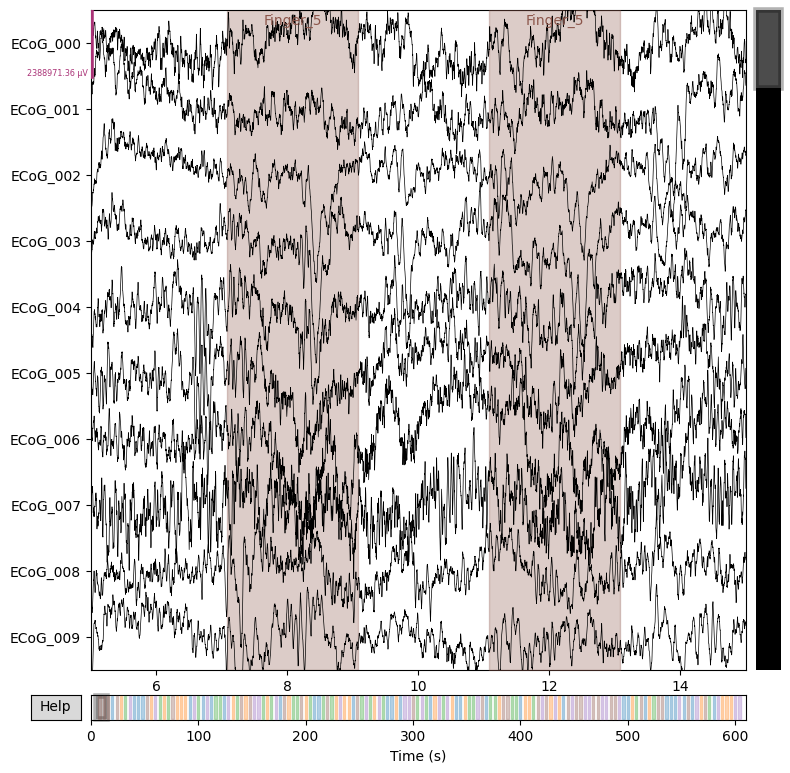

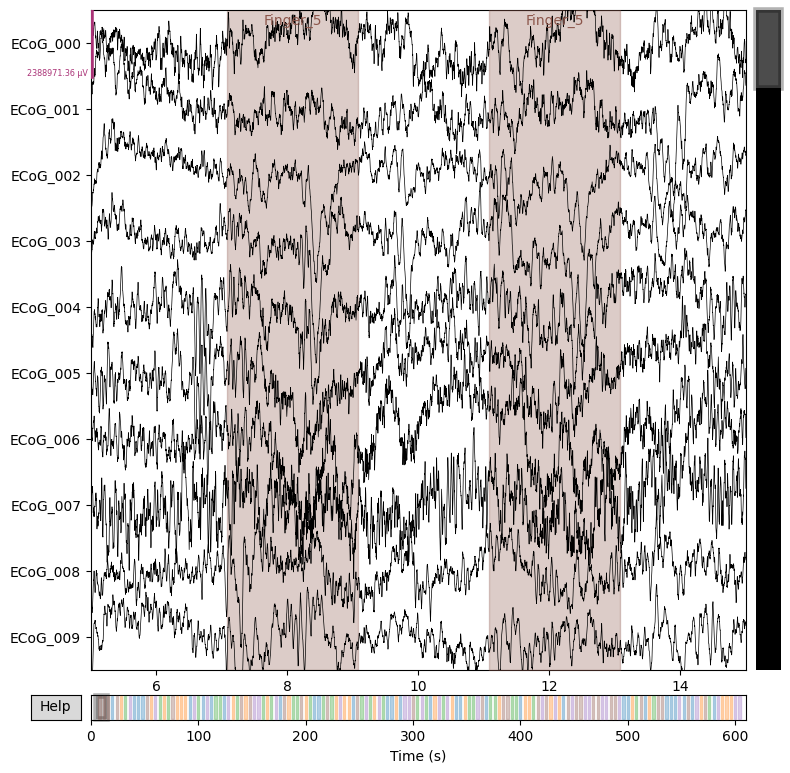

In [ ]:
raw.plot(start=5.0, duration=10.0, n_channels=10, decim='auto', scalings='auto', block=False)

- decide whether to implement Millers PSC decomposition to isolate a true broadband power-law component.

- PSC own internal step (operates on log-power across frequencies to fit/remove power-law trend) - are broadband/beta features cleanly separated for analysis or partially confounded with each other

- sliding window above chance decoding timeline relative to that kinematic onset "change window"; moving from fixed cue locked epoch to dg-derived onset which will vary in latency from t_on with a sliding window of decoding within it to find the earliest window where finger identity is decodable above chance
---
1. section on movement onset detection
2. confirm which finger's dg column to threshold per trial
  - use dg column matching stim_id
  - within that column, take first threshold creossing after t_on as onset
3. decide sliding-window decoding parameters
4. define "above chance" statistically
 - build null distribution of "accuracy we see by chance"
 - pool across subjects or do it separately?

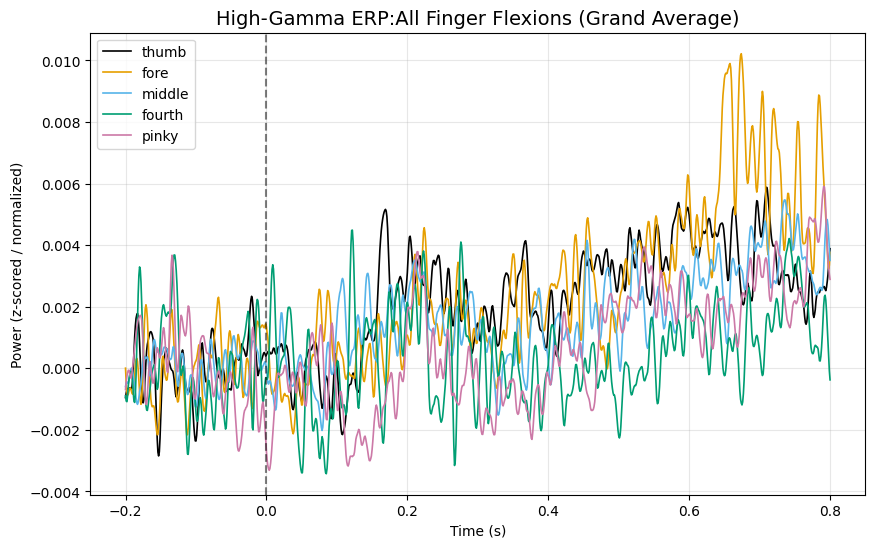

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter and extract broadband envelope
raw_gamma = raw.copy().filter(l_freq=70., h_freq=150., fir_design='firwin', verbose=False)
raw_gamma.apply_hilbert(envelope=True)

# 2. Extract epochs based on all fingers
events, event_id = mne.events_from_annotations(raw_gamma, verbose=False)
epochs_gamma = mne.Epochs(raw_gamma, events, event_id, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)

# 3. Create Evoked responses for each category
# event_id is usually {'Category_1': 1, 'Category_2': 2}
finger_1 = epochs_gamma['Finger_1'].average()
finger_2 = epochs_gamma['Finger_2'].average()
finger_3 = epochs_gamma['Finger_3'].average()
finger_4 = epochs_gamma['Finger_4'].average()
finger_5 = epochs_gamma['Finger_5'].average()


# 4. Plot overlapping ERPs
# We'll use the average across all channels or a specific responsive channel
fig, ax = plt.subplots(figsize=(10, 6))

# Average across all ECoG channels
times = finger_1.times
finger1 = finger_1.data.mean(axis=0)
finger2 = finger_2.data.mean(axis=0)
finger3 = finger_3.data.mean(axis=0)
finger4 = finger_4.data.mean(axis=0)
finger5 = finger_5.data.mean(axis=0)


ax.plot(times, finger1, label='thumb', color='#000000', linewidth=1.2)
ax.plot(times, finger2, label='fore', color='#E69F00', linewidth=1.2)
ax.plot(times, finger3, label='middle', color='#56B4E9', linewidth=1.2)
ax.plot(times, finger4, label='fourth', color='#009E73', linewidth=1.2)
ax.plot(times, finger5, label='pinky', color='#CC79A7', linewidth=1.2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("High-Gamma ERP:All Finger Flexions (Grand Average)", fontsize=14)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (z-scored / normalized)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

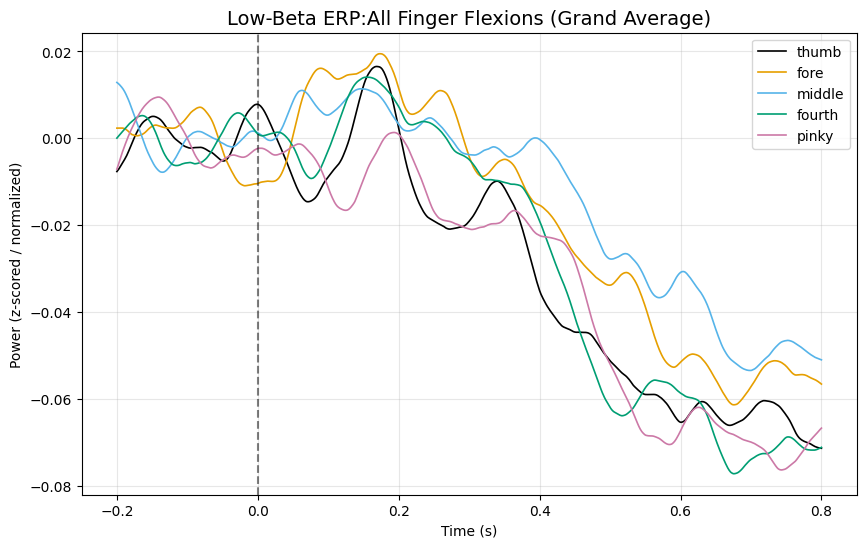

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Filter and extract Low-Beta envelope  (accounted for 1/f ?)
raw_beta = raw.copy().filter(l_freq=12., h_freq=25., fir_design='firwin', verbose=False)
raw_beta.apply_hilbert(envelope=True)

# 2. Extract epochs based on all fingers
events, event_id = mne.events_from_annotations(raw_beta, verbose=False)
epochs_beta = mne.Epochs(raw_beta, events, event_id, tmin=-0.2, tmax=0.8, baseline=(-0.2, 0), preload=True, verbose=False)

# 3. Create Evoked responses for each category
# event_id is usually {'Category_1': 1, 'Category_2': 2}
finger_1 = epochs_beta['Finger_1'].average()
finger_2 = epochs_beta['Finger_2'].average()
finger_3 = epochs_beta['Finger_3'].average()
finger_4 = epochs_beta['Finger_4'].average()
finger_5 = epochs_beta['Finger_5'].average()


# 4. Plot overlapping ERPs
# We'll use the average across all channels or a specific responsive channel
fig, ax = plt.subplots(figsize=(10, 6))

# Average across all ECoG channels
times = finger_1.times
finger1 = finger_1.data.mean(axis=0)
finger2 = finger_2.data.mean(axis=0)
finger3 = finger_3.data.mean(axis=0)
finger4 = finger_4.data.mean(axis=0)
finger5 = finger_5.data.mean(axis=0)


ax.plot(times, finger1, label='thumb', color='#000000', linewidth=1.2)
ax.plot(times, finger2, label='fore', color='#E69F00', linewidth=1.2)
ax.plot(times, finger3, label='middle', color='#56B4E9', linewidth=1.2)
ax.plot(times, finger4, label='fourth', color='#009E73', linewidth=1.2)
ax.plot(times, finger5, label='pinky', color='#CC79A7', linewidth=1.2)

ax.axvline(0, color='black', linestyle='--', alpha=0.5)
ax.set_title("Low-Beta ERP:All Finger Flexions (Grand Average)", fontsize=14)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Power (z-scored / normalized)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
ch_names

['ECoG_000',
 'ECoG_001',
 'ECoG_002',
 'ECoG_003',
 'ECoG_004',
 'ECoG_005',
 'ECoG_006',
 'ECoG_007',
 'ECoG_008',
 'ECoG_009',
 'ECoG_010',
 'ECoG_011',
 'ECoG_012',
 'ECoG_013',
 'ECoG_014',
 'ECoG_015',
 'ECoG_016',
 'ECoG_017',
 'ECoG_018',
 'ECoG_019',
 'ECoG_020',
 'ECoG_021',
 'ECoG_022',
 'ECoG_023',
 'ECoG_024',
 'ECoG_025',
 'ECoG_026',
 'ECoG_027',
 'ECoG_028',
 'ECoG_029',
 'ECoG_030',
 'ECoG_031',
 'ECoG_032',
 'ECoG_033',
 'ECoG_034',
 'ECoG_035',
 'ECoG_036',
 'ECoG_037',
 'ECoG_038',
 'ECoG_039',
 'ECoG_040',
 'ECoG_041',
 'ECoG_042',
 'ECoG_043',
 'ECoG_044',
 'ECoG_045',
 'ECoG_046',
 'ECoG_047',
 'ECoG_048',
 'ECoG_049',
 'ECoG_050',
 'ECoG_051',
 'ECoG_052',
 'ECoG_053',
 'ECoG_054',
 'ECoG_055',
 'ECoG_056',
 'ECoG_057',
 'ECoG_058',
 'ECoG_059',
 'ECoG_060',
 'ECoG_061',
 'ECoG_062',
 'ECoG_063',
 'ECoG_064',
 'ECoG_065',
 'ECoG_066',
 'ECoG_067',
 'ECoG_068',
 'ECoG_069',
 'ECoG_070',
 'ECoG_071',
 'ECoG_072',
 'ECoG_073',
 'ECoG_074',
 'ECoG_075',
 'ECoG_076',

## **Plot psd for which finger moves. Use that channel for the finger of interest.**

## **Visually filter out channels that dont provide any interest**

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


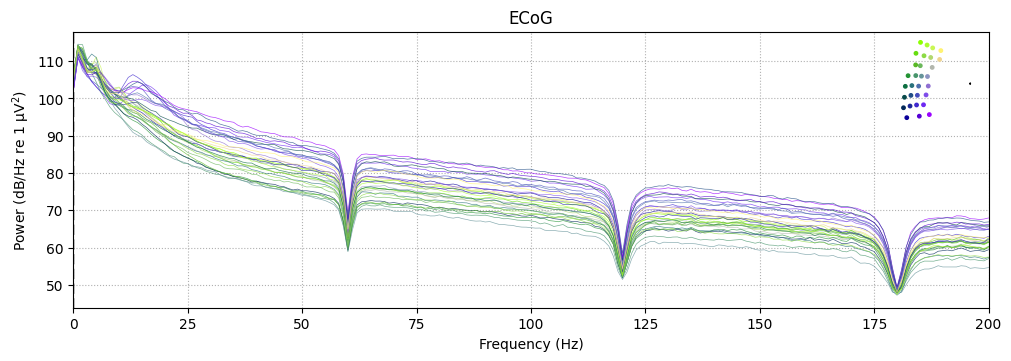

In [ ]:
psd = raw.compute_psd(fmin = 0, fmax = 200, n_fft = 1000, n_per_seg = 1000,
                window = 'hamming', method = 'welch',
                picks=ch_names[:30]).plot(average = False);

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


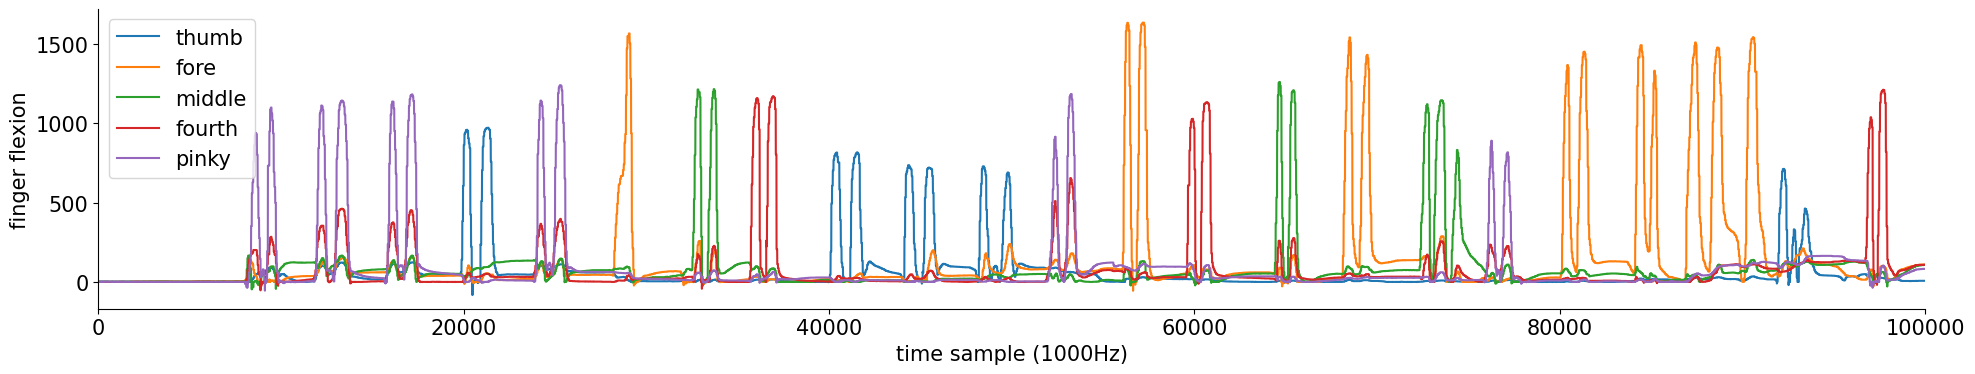

In [10]:
# finger data from the dataglove
dg = dat['dg']
nfingers = dg.shape[1]

for j in range(dg.shape[-1]):
  plt.plot(dg[:100000, j])

plt.xlabel('time sample (1000Hz)')
plt.ylabel('finger flexion')
plt.xlim([0, 100000])
plt.legend(dat['stimtext'])
plt.show()

### PSD visual check for filtering results

Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


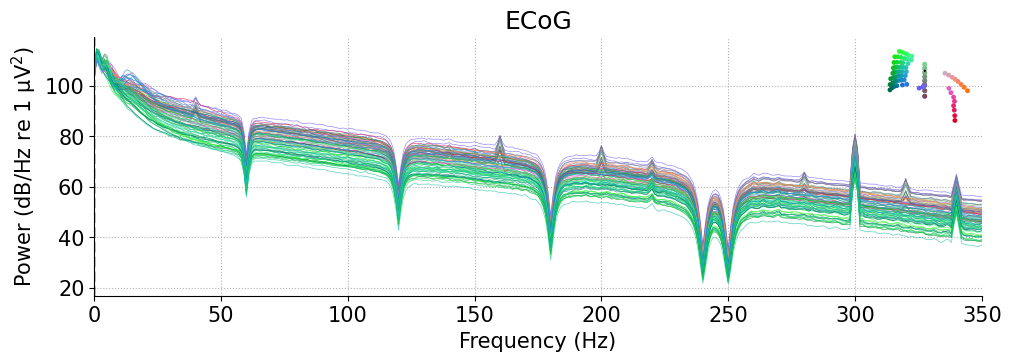

In [71]:
psd = raw.compute_psd(fmin = 0, fmax = 350, n_fft = 1000, n_per_seg = 1000,
                window = 'hann', method = 'welch',
                picks=ch_names[:]).plot(average = False);

## Correlations between high freq and low freq bands, and each digit

In [73]:
##Understand and comment accurately

# compute correlations between high frequency band and each digit
from scipy import signal
V = dat['V'].astype('float32')

#apply highpass filter before isolating bands of interest (remove drift:PP)
b, a = signal.butter(3, [0.5], btype='high', fs=1000)
V = signal.filtfilt(b, a, V, 0)

#remove high frequency
b, a = signal.butter(4, 250, btype='lowpass', fs=1000)
V = signal.filtfilt(b, a, V, 0)

##Bands of interest & square them
#high freq bandpass (gamma)
b, a = signal.butter(3, [50, 150], btype='bandpass', fs=1000)
V_high = signal.filtfilt(b, a, V, 0)
V_high = np.abs(V_high)**2


##Smooth out to handle squaring
#lowpass (smooth it out, needs to happen after squaring)
b, a = signal.butter(3, [3], btype='lowpass', fs=1000)
V = signal.filtfilt(b, a, V, 0)


#low freq bandpass (beta)
b, a = signal.butter(3, [13, 25], btype='bandpass', fs=1000)
V_low = signal.filtfilt(b, a, V, 0)
V_low = np.abs(V_low)**2


nt, nchan = V.shape


#lowpass (smooth it out, needs to happen after squaring)
b, a = signal.butter(3, [3], btype='lowpass', fs=1000)
V = signal.filtfilt(b, a, V, 0)


Creating RawArray with float64 data, n_channels=168, n_times=610040
    Range : 0 ... 610039 =      0.000 ...   610.039 secs
Ready.
Filtered MNE Raw object ready.
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_11139/1614389747.py:27: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  ).plot(average=False)


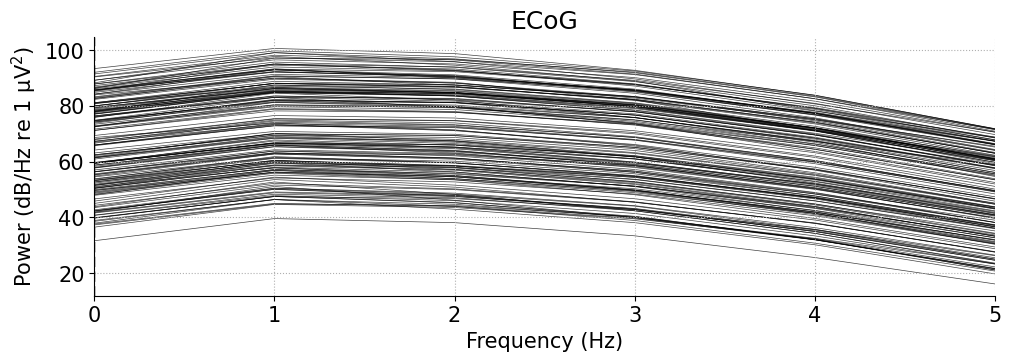

In [72]:
psd = raw_filtered.compute_psd(
    fmin=0,
    fmax=5,
    n_fft=1000,
    n_per_seg=1000,
    window='hann',
    method='welch'
).plot(average=False)


### Move down after Hilbert

In [49]:
# cc_low = np.zeros((nchan,nfingers))
# for j in range(nchan):
#   for k in range(nfingers):
#     cc_low[j, k] = np.corrcoef(V_low[:, j], dg[:, k])[0, 1]

In [50]:
# cc_high = np.zeros((nchan,nfingers))
# for j in range(nchan):
#   for k in range(nfingers):
#     cc_high[j, k] = np.corrcoef(V_high[:, j], dg[:, k])[0, 1]

Text(0.5, 1.0, 'High freq (gamma)')

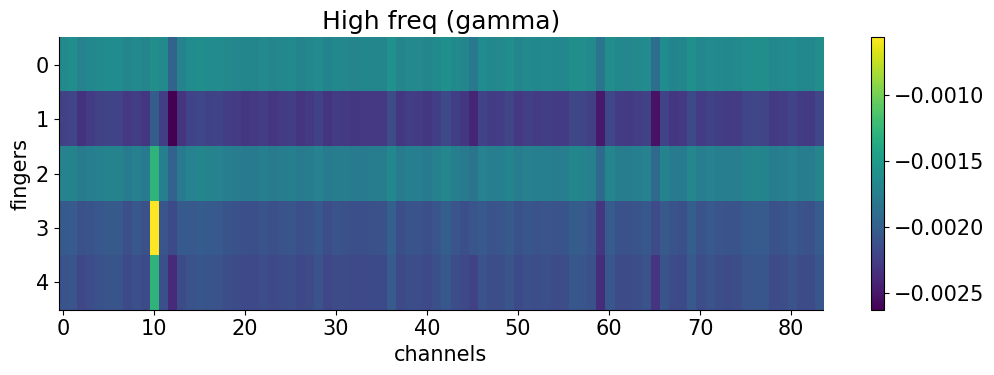

In [51]:
# #Plot high_band correlation matrix
# plt.subplot(1, 2, 1)
# plt.imshow(cc_high.T, aspect='auto')
# plt.colorbar()
# plt.xlabel('channels')
# plt.ylabel('fingers')
# plt.title('High freq (gamma)')


Text(0.5, 1.0, 'Low freq (beta)')

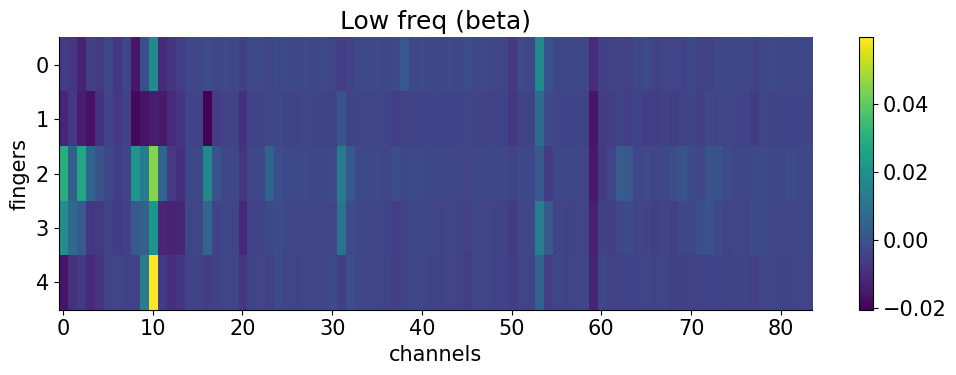

In [52]:
# #Plot low_band correlation matrix

# plt.subplot(1, 2, 2)
# plt.imshow(cc_low.T, aspect='auto')
# plt.colorbar()
# plt.xlabel('channels')
# plt.ylabel('fingers')
# plt.title('Low freq (beta)')

## Hilbert transform prior to correlation
- can do wavelet to see if we observe same phase of rhythms regardless of transform

In [ ]:
#Perform on filtered signals (follow literature)


- Identify channels of interest
- Chunk into 2 second windows (t_on - t_off)
- Find movement intiation point; from movement onset (pre-rest period - t_on - movement_onset) - (note: can use pre-rest for baseline correction);  select channels that only concern themselves with movement (then need to use)
- Isolate fingers of interest

## Perform PCA on ECoG data

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA, FastICA

import mne
from mne.datasets import sample
from mne.decoding import UnsupervisedSpatialFilter

pca = UnsupervisedSpatialFilter(PCA(10), average=False)

In [ ]:
X = raw.get_data()
X_red = X[:10]

In [ ]:
pca_data = pca.fit_transform(X_red)